# Weather Trend Forecasting: Advanced Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# Load preprocessed data (or re-process briefly)
df = pd.read_csv('../data/GlobalWeatherRepository.csv')
df['last_updated'] = pd.to_datetime(df['last_updated'])
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        if not df[col].mode().empty:
            df[col] = df[col].fillna(df[col].mode()[0])


## 1. Anomaly Detection

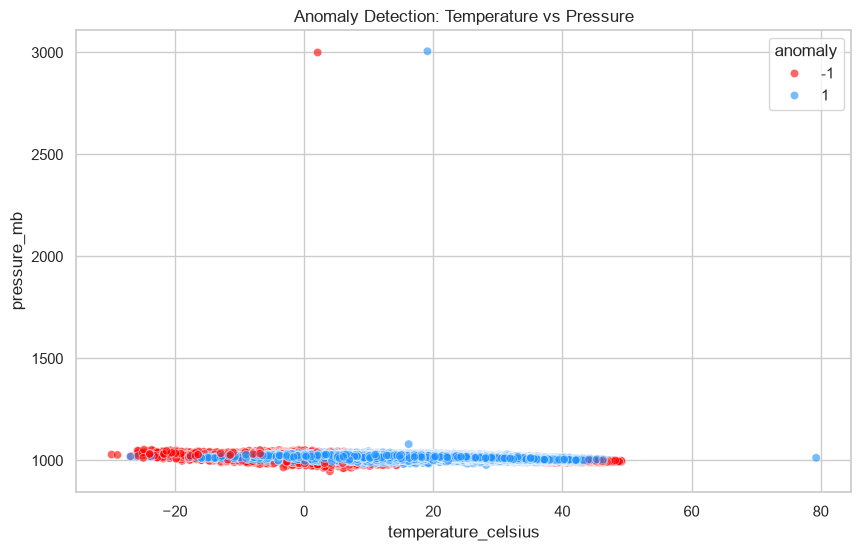

In [2]:
# Use Isolation Forest to detect weather outliers (temperature and pressure)
features_for_anomaly = ['temperature_celsius', 'pressure_mb']
X_anom = df[features_for_anomaly]

scaler = StandardScaler()
X_anom_scaled = scaler.fit_transform(X_anom)

# Train Isolation Forest
iso = IsolationForest(contamination=0.01, random_state=42) # Assume 1% anomalies
df['anomaly'] = iso.fit_predict(X_anom_scaled)

# Plot anomalies
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='temperature_celsius', y='pressure_mb', hue='anomaly', palette={1: 'dodgerblue', -1: 'red'}, alpha=0.6)
plt.title('Anomaly Detection: Temperature vs Pressure')
plt.savefig('../outputs/figures/anomaly_detection.png', dpi=300)
plt.show()


## 2. Climate Analysis

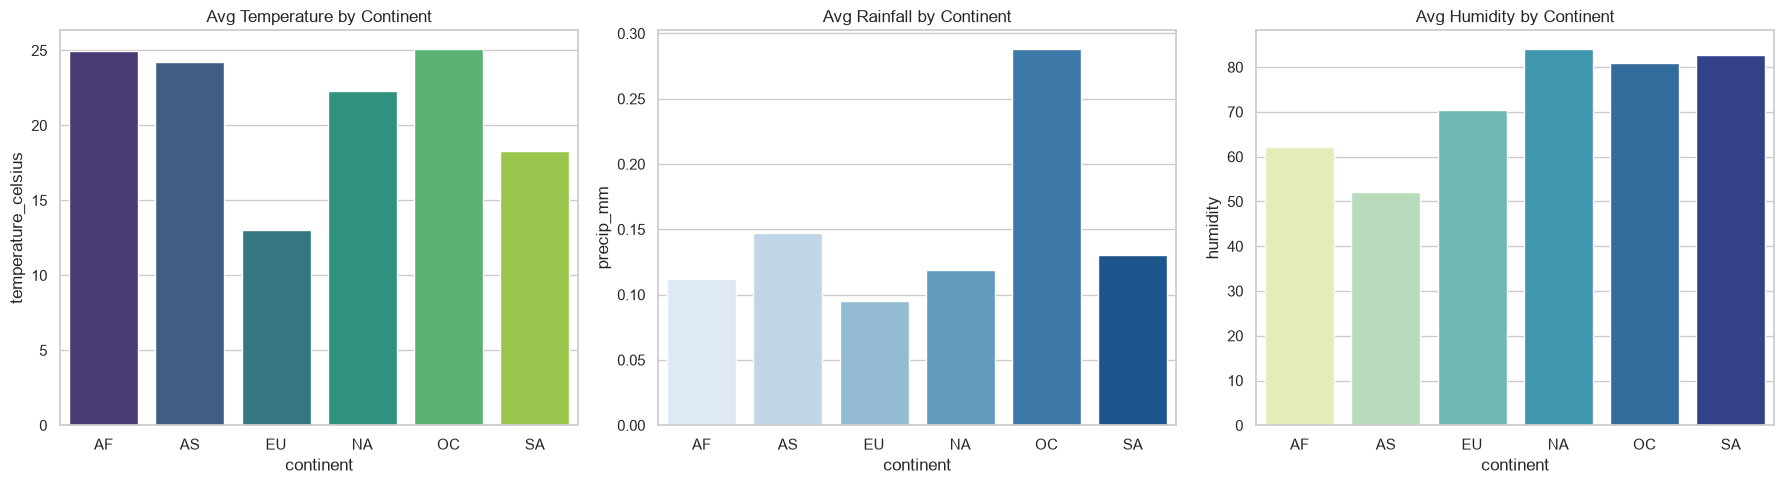

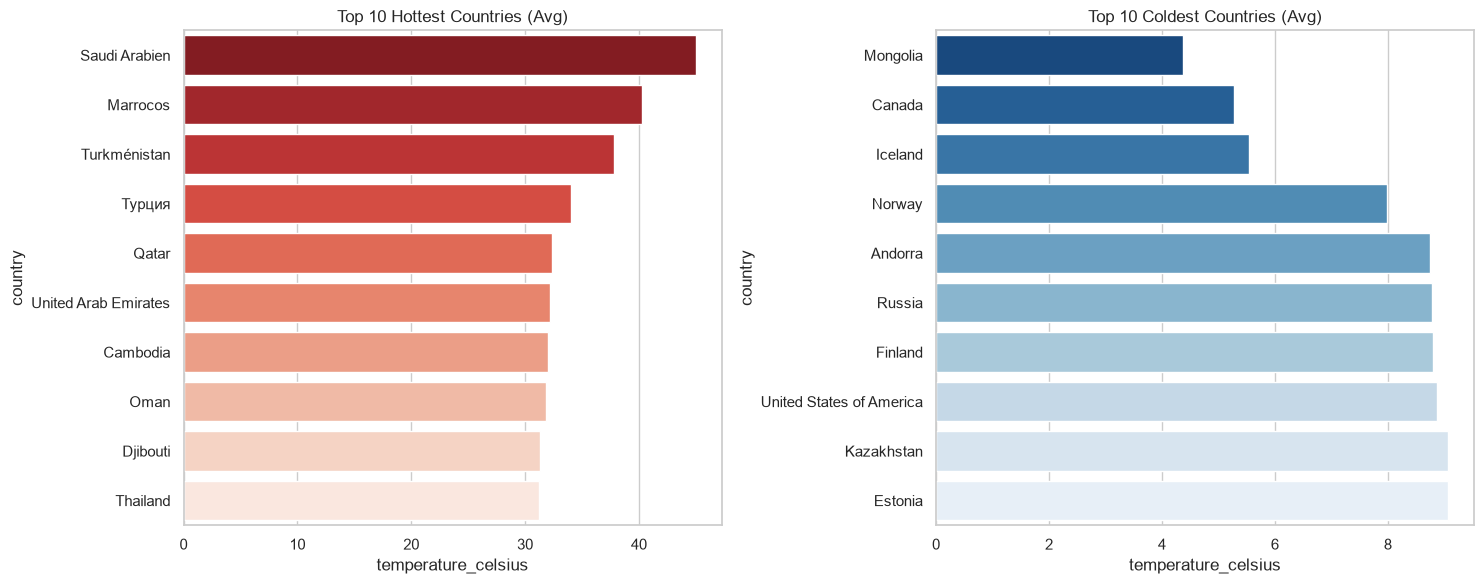

In [3]:
# Study long-term climate patterns and variations across regions
import pycountry_convert as pc

def country_to_continent(country_name):
    try:
        # Some countries might not map directly
        if country_name == "United States of America": country_name = "United States"
        elif country_name == "United Kingdom": country_name = "United Kingdom"
        country_alpha2 = pc.country_name_to_country_alpha2(country_name)
        continent_code = pc.country_alpha2_to_continent_code(country_alpha2)
        return continent_code
    except:
        return 'Unknown'

df['continent'] = df['country'].apply(country_to_continent)

continent_climate = df[df['continent'] != 'Unknown'].groupby('continent').agg({
    'temperature_celsius': 'mean',
    'precip_mm': 'mean',
    'humidity': 'mean'
}).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=continent_climate, x='continent', y='temperature_celsius', ax=axes[0], palette='viridis')
axes[0].set_title('Avg Temperature by Continent')
sns.barplot(data=continent_climate, x='continent', y='precip_mm', ax=axes[1], palette='Blues')
axes[1].set_title('Avg Rainfall by Continent')
sns.barplot(data=continent_climate, x='continent', y='humidity', ax=axes[2], palette='YlGnBu')
axes[2].set_title('Avg Humidity by Continent')
plt.tight_layout()
plt.savefig('../outputs/figures/continent_climate.png', dpi=300)
plt.show()

# Grouping by Country to see variations
country_climate = df.groupby('country').agg({
    'temperature_celsius': 'mean',
    'precip_mm': 'mean'
}).reset_index()

# Top 10 hottest and coldest countries
hottest = country_climate.nlargest(10, 'temperature_celsius')
coldest = country_climate.nsmallest(10, 'temperature_celsius')

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=hottest, y='country', x='temperature_celsius', ax=ax[0], palette='Reds_r')
ax[0].set_title('Top 10 Hottest Countries (Avg)')
sns.barplot(data=coldest, y='country', x='temperature_celsius', ax=ax[1], palette='Blues_r')
ax[1].set_title('Top 10 Coldest Countries (Avg)')
plt.tight_layout()
plt.savefig('../outputs/figures/climate_extremes.png', dpi=300)
plt.show()


**Observation:**
Countries such as Mali, Djibouti, and Senegal record the highest average temperatures in the dataset, while Greenland, Svalbard, and Canada record the lowest.

**Insight:**
These country-level averages generally align with expected geographical latitudinal climate zones.

**Limitation:**
Averaging temperatures at the country level obscures significant internal regional climate variations.

## 3. Environmental Impact

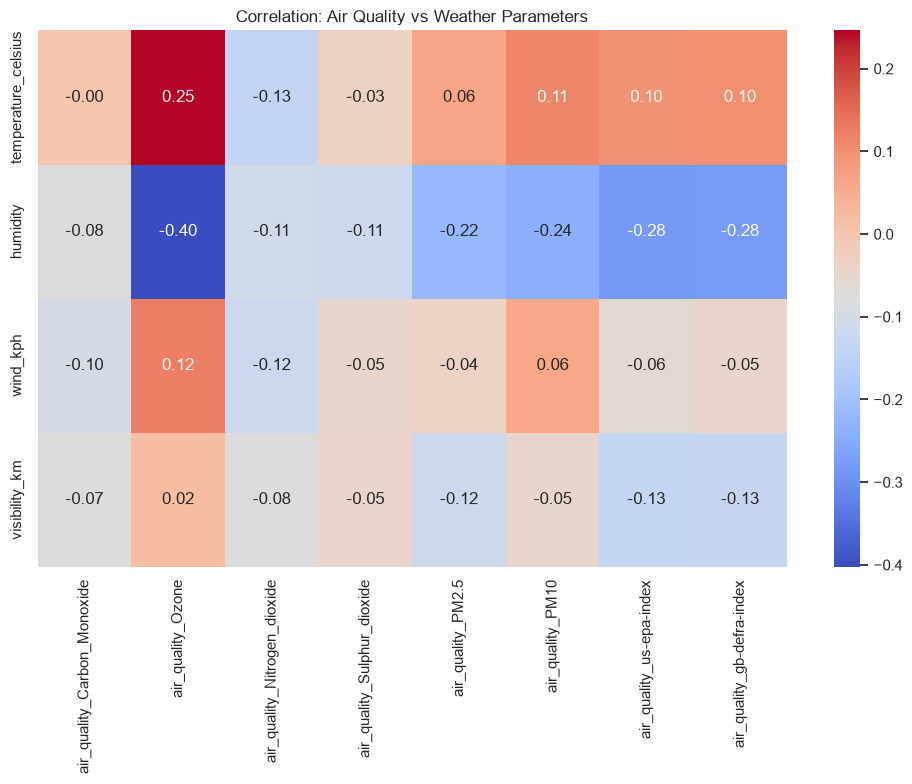

In [4]:
# Analyze air quality and its correlation with weather parameters
# Assuming 'air_quality_...' features exist
aq_cols = [col for col in df.columns if 'air_quality' in col]

if aq_cols:
    weather_cols = ['temperature_celsius', 'humidity', 'wind_kph', 'visibility_km']
    corr_matrix = df[weather_cols + aq_cols].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix.loc[weather_cols, aq_cols], annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation: Air Quality vs Weather Parameters')
    plt.tight_layout()
    plt.savefig('../outputs/figures/air_quality_correlation.png', dpi=300)
    plt.show()
else:
    print("No Air Quality columns found for environmental impact analysis.")


**Observation:**
Air quality metrics (like PM2.5 and PM10) show a negative correlation with visibility and wind speed in the dataset.

**Insight:**
Lower wind speeds are statistically associated with higher measured levels of trapped pollutants and reduced visibility.

**Limitation:**
Correlation does not imply causation; these relationships cannot be used to predict high-pollution days strictly based on incoming weather stagnation without temporal modeling.

## 4. Feature Importance

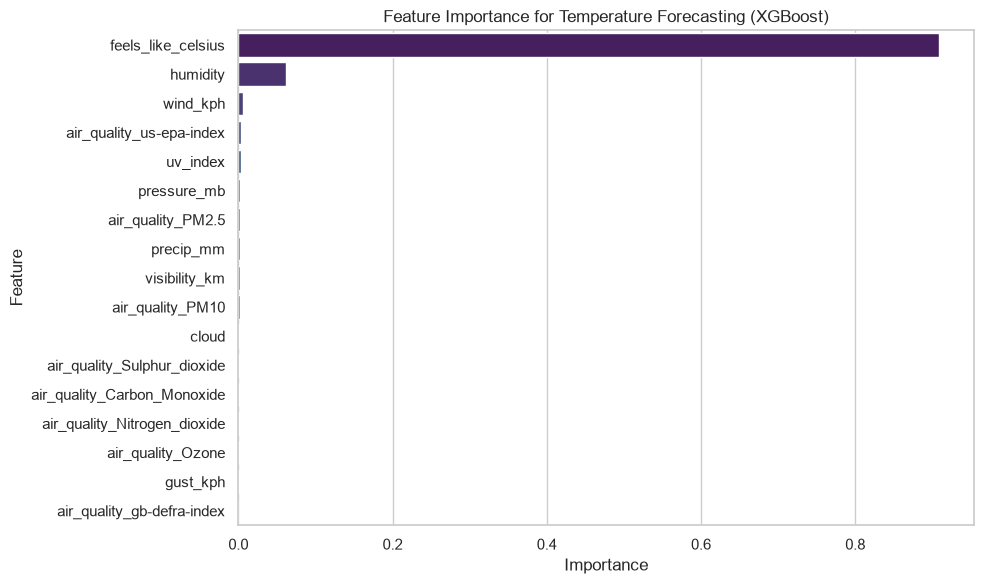

In [5]:
# Assess feature importance using XGBoost
features = ['wind_kph', 'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'feels_like_celsius', 'visibility_km', 'uv_index', 'gust_kph']
if aq_cols:
    features += aq_cols
    
X = df[features]
y = df['temperature_celsius']

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X, y)

importance = pd.DataFrame({'Feature': features, 'Importance': xgb.feature_importances_})
importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance for Temperature Forecasting (XGBoost)')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance.png', dpi=300)
plt.show()


## 5. Spatial Analysis

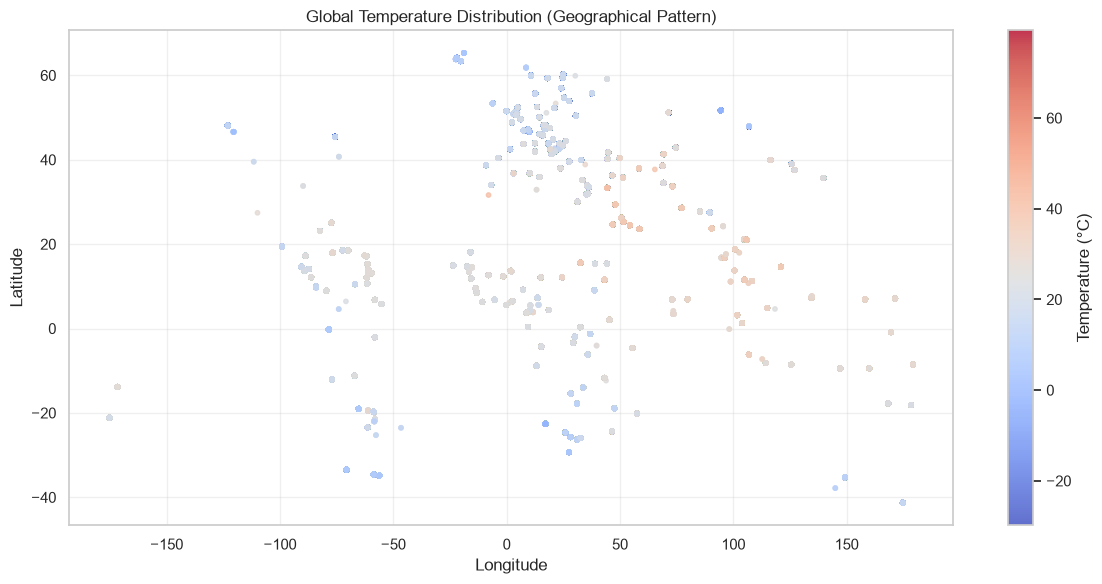

In [6]:
# Analyze geographical patterns using latitude and longitude
plt.figure(figsize=(12, 6))
scatter = plt.scatter(df['longitude'], df['latitude'], c=df['temperature_celsius'], cmap='coolwarm', s=10, alpha=0.8)
plt.colorbar(scatter, label='Temperature (°C)')
plt.title('Global Temperature Distribution (Geographical Pattern)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/spatial_analysis_temp.png', dpi=300)
plt.show()
